# Google FRAMES Benchmark — EDA & Preprocessing

In [22]:
# Imports 
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_colwidth', 120)


## 1. Loading the dataset

Loading the dataset using code located under "use this dataset" and "pandas" at https://huggingface.co/datasets/google/frames-benchmark?library=pandas

In [23]:
df = pd.read_csv("hf://datasets/google/frames-benchmark/test.tsv", sep="\t")
df.head()

,Unnamed: 0,Prompt,Answer,wikipedia_link_1,wikipedia_link_2,wikipedia_link_3,wikipedia_link_4,wikipedia_link_5,wikipedia_link_6,wikipedia_link_7,wikipedia_link_8,wikipedia_link_9,wikipedia_link_10,wikipedia_link_11+,reasoning_types,wiki_links
0,0,If my future wife has the same first name as the 15th first lady of the United States' mother and her surname is the...,Jane Ballou,https://en.wikipedia.org/wiki/President_of_the_United_States,https://en.wikipedia.org/wiki/James_Buchanan,https://en.wikipedia.org/wiki/Harriet_Lane,https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States_who_died_in_office,https://en.wikipedia.org/wiki/James_A._Garfield,NaN,NaN,NaN,NaN,NaN,NaN,Multiple constraints,"['https://en.wikipedia.org/wiki/President_of_the_United_States', 'https://en.wikipedia.org/wiki/James_Buchanan', 'ht..."
1,1,Imagine there is a building called Bronte tower whose height in feet is the same number as the dewey decimal classif...,37th,https://en.wikipedia.org/wiki/Charlotte_Bront%C3%AB,https://en.wikipedia.org/wiki/Jane_Eyre,https://en.wikipedia.org/wiki/List_of_tallest_buildings_in_New_York_City,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Numerical reasoning | Tabular reasoning | Multiple constraints,"['https://en.wikipedia.org/wiki/Charlotte_Bront%C3%AB', 'https://en.wikipedia.org/wiki/Jane_Eyre', 'https://en.wikip..."
2,2,How many years earlier would Punxsutawney Phil have to be canonically alive to have made a Groundhog Day prediction ...,87,https://en.wikipedia.org/wiki/Punxsutawney_Phil,https://en.wikipedia.org/wiki/United_States_Capitol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Numerical reasoning | Multiple constraints | Temporal reasoning,"['https://en.wikipedia.org/wiki/Punxsutawney_Phil', 'https://en.wikipedia.org/wiki/United_States_Capitol']"
3,3,"As of August 1, 2024, which country were holders of the FIFA World Cup the last time the UEFA Champions League was w...",France,https://en.wikipedia.org/wiki/FIFA_World_Cup,https://en.wikipedia.org/wiki/London,https://en.wikipedia.org/wiki/UEFA_Champions_League,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tabular reasoning | Multiple constraints | Temporal reasoning,"['https://en.wikipedia.org/wiki/FIFA_World_Cup', 'https://en.wikipedia.org/wiki/London', 'https://en.wikipedia.org/w..."
4,4,What is the name of the vocalist from the first band to make it in the top 200 under the record label that produced ...,Jens Kidman,https://en.wikipedia.org/wiki/Dismal_Euphony,https://en.wikipedia.org/wiki/All_Little_Devils,https://en.wikipedia.org/wiki/Nuclear_Blast,https://en.wikipedia.org/wiki/Meshuggah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Multiple constraints,"['https://en.wikipedia.org/wiki/Dismal_Euphony', 'https://en.wikipedia.org/wiki/All_Little_Devils', 'https://en.wiki..."


In [24]:
df.columns

Index(['Unnamed: 0', 'Prompt', 'Answer', 'wikipedia_link_1',
       'wikipedia_link_2', 'wikipedia_link_3', 'wikipedia_link_4',
       'wikipedia_link_5', 'wikipedia_link_6', 'wikipedia_link_7',
       'wikipedia_link_8', 'wikipedia_link_9', 'wikipedia_link_10',
       'wikipedia_link_11+', 'reasoning_types', 'wiki_links'],
      dtype='object')

In [25]:
print(f"Dataset has {len(df)} rows")
print("Columns:")
for col in df.columns:
    print(f"- {col}")


Dataset has 824 rows
Columns:
- Unnamed: 0
- Prompt
- Answer
- wikipedia_link_1
- wikipedia_link_2
- wikipedia_link_3
- wikipedia_link_4
- wikipedia_link_5
- wikipedia_link_6
- wikipedia_link_7
- wikipedia_link_8
- wikipedia_link_9
- wikipedia_link_10
- wikipedia_link_11+
- reasoning_types
- wiki_links


In [26]:
df.dtypes

Unnamed: 0             int64
Prompt                object
Answer                object
wikipedia_link_1      object
wikipedia_link_2      object
wikipedia_link_3      object
wikipedia_link_4      object
wikipedia_link_5      object
wikipedia_link_6      object
wikipedia_link_7      object
wikipedia_link_8      object
wikipedia_link_9      object
wikipedia_link_10     object
wikipedia_link_11+    object
reasoning_types       object
wiki_links            object
dtype: object

In [27]:
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== Missing values ===
Unnamed: 0              0
Prompt                  0
Answer                  0
wikipedia_link_1        0
wikipedia_link_2        0
wikipedia_link_3      310
wikipedia_link_4      598
wikipedia_link_5      732
wikipedia_link_6      771
wikipedia_link_7      788
wikipedia_link_8      801
wikipedia_link_9      807
wikipedia_link_10     810
wikipedia_link_11+    811
reasoning_types         0
wiki_links              0
dtype: int64

Duplicate rows: 0


The missing values observed in the dataset are expected given the structure. The Frames dataset includes multiple Wikipedia link columns, but not every example has the same number of supporting links. As a result, the later link columns naturally have more missing values because they only have non-missing values when an example has many sources. 

Additionally, there are no duplicate rows, which indicates that each prompt-answer pair is unique in the dataset.

## 3. Exploratory Data Analysis

### 3.1 Reasoning Type Distribution

In [28]:
# Check reasoning types in the dataset
reasoning_col = df["reasoning_types"]

# Handle case where values are lists vs single labels
if isinstance(reasoning_col.iloc[0], list):
    all_types = []
    for v in reasoning_col:
        all_types.extend(v)
else:
    all_types = reasoning_col.tolist()

print("Reasoning type distribution:")
print(pd.Series(all_types).value_counts())


Reasoning type distribution:
Multiple constraints                                                                                     265
Numerical reasoning                                                                                       58
Tabular reasoning | Multiple constraints                                                                  50
Temporal reasoning                                                                                        50
Multiple constraints | Temporal reasoning                                                                 44
Tabular reasoning                                                                                         41
Numerical reasoning | Multiple constraints | Temporal reasoning                                           39
Numerical reasoning | Temporal reasoning                                                                  30
Numerical reasoning | Multiple constraints                                                         

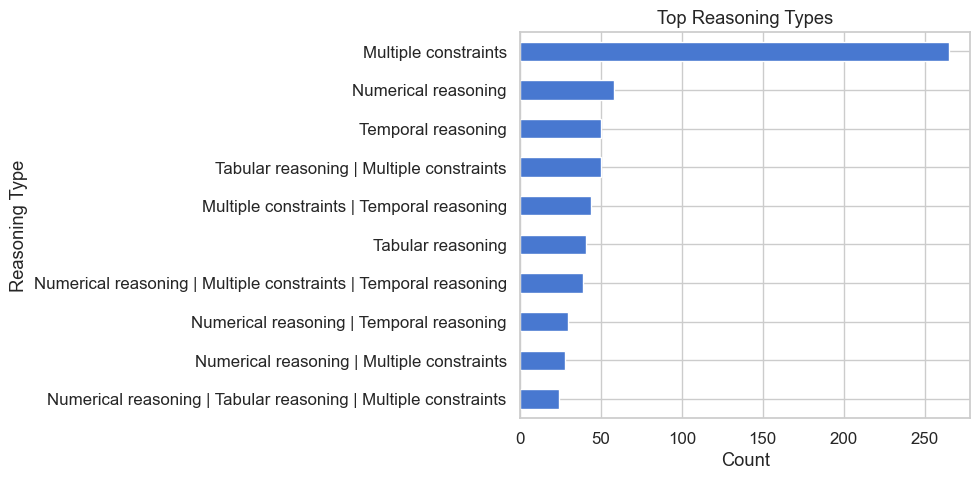

In [29]:
# Get counts
type_counts = pd.Series(all_types).value_counts()

# Keep only top 10 for readability
top_counts = type_counts.head(10)

plt.figure(figsize=(10, 5))
top_counts.sort_values().plot(kind='barh')

plt.title("Top Reasoning Types")
plt.xlabel("Count")
plt.ylabel("Reasoning Type")

plt.tight_layout()
plt.show()


The plot shows the most frequent reasoning types in the dataset. The most prominent reasoning type is **"Multiple constraints"**, which appears significantly more often than any other type. This suggests that many questions require combining several constraints to reach an answer.

We can also see that **"Numerical reasoning"**, **"Temporal reasoning"**, and **"Tabular reasoning"** appear somewhat frequent, often as a standalone reasoning type or in combination with others. 

Overall, the distribution suggests that the dataset is focused on complex, multi-label reasoning tasks rather than isolated reasoning categories.

### 3.2 Question Length Distribution

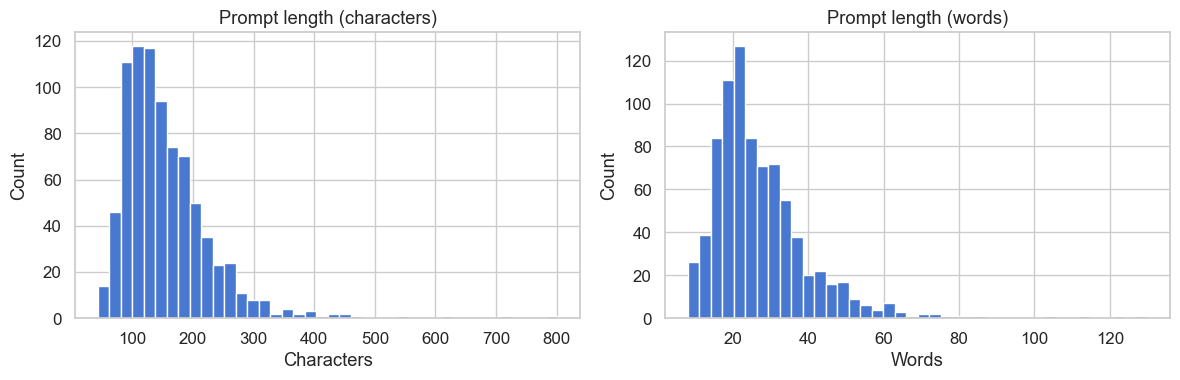


Length statistics:
         char_len    word_len
count  824.000000  824.000000
mean   155.330097   27.609223
std     75.330154   13.373146
min     43.000000    8.000000
25%    106.000000   19.000000
50%    139.000000   24.500000
75%    185.250000   33.000000
max    801.000000  130.000000


In [30]:
prompt_col = "Prompt"

if prompt_col in df.columns:

    q_char_len = df[prompt_col].astype(str).apply(len)
    q_word_len = df[prompt_col].astype(str).apply(lambda x: len(x.split()))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(q_char_len, bins=40)
    plt.title("Prompt length (characters)")
    plt.xlabel("Characters")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(q_word_len, bins=40)
    plt.title("Prompt length (words)")
    plt.xlabel("Words")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    print("\nLength statistics:")
    print(pd.DataFrame({
        "char_len": q_char_len,
        "word_len": q_word_len
    }).describe())

else:
    print("Prompt column not found. Columns:", list(df.columns))


From the histogram above and the summary statistics, we can observe the length of the prompts. Most prompts are relatively short to medium in length. The average prompt contains about 155 characters and 28 words. The median (50%) is slightly lower at about 139 characters and 24.5 words, which suggests a right-skew in the distribution. This can also be seen in the plots, where most values are around shorter lengths, and there is a long tail extending to longer prompts. 

Overall, the dataset mostly consist of fairly short prompts, with some outliers that are much more detailed or complex.

### 3.3 Answer Length Distribution

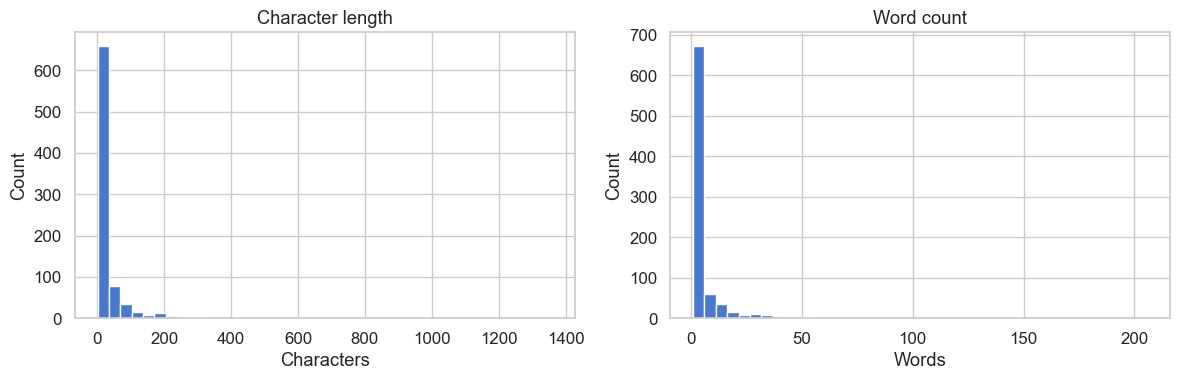


Summary statistics:
       char_len  word_len
count     824.0     824.0
mean       30.7       5.2
std        66.2      10.5
min         1.0       1.0
25%         7.0       1.0
50%        13.0       2.0
75%        26.0       4.0
max      1360.0     206.0


In [31]:
answer_col = "Answer"

if answer_col in df.columns:

    char_len = df[answer_col].astype(str).apply(len)
    word_len = df[answer_col].astype(str).apply(lambda x: len(x.split()))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(char_len.dropna(), bins=40)
    plt.title("Character length")
    plt.xlabel("Characters")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(word_len.dropna(), bins=40)
    plt.title("Word count")
    plt.xlabel("Words")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    print("\nSummary statistics:")
    print(pd.DataFrame({
        "char_len": char_len,
        "word_len": word_len
    }).describe().round(1))

else:
    print("Answer column not found. Columns:", list(df.columns))


The histograms above show the distribution of the answer length in the dataset. 

Most answers are very short. From the summary statistics, the median answer (50%) is only 13 words or 2 words. The average is at about 30 characterse and 5 words. The median being higher than the average suggests that there are a few much longer answers pulling the average up. This is also visible in the histrogram plot above, showing that most values are clustered near the lower end, while a very small amount are much longer. The maximum values of 1360 characters or 206 words show that there are some outliers in the dataset.

Overall, the data is heavily skewed towards short answers, with only a few long responses.

### 3.4 Number of Wikipedia Links per Example

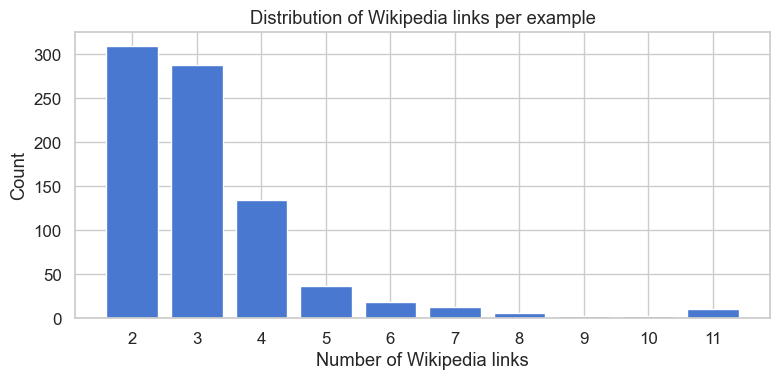


Summary statistics:
count    824.00
mean       3.20
std        1.58
min        2.00
25%        2.00
50%        3.00
75%        4.00
max       11.00
dtype: float64


In [32]:
link_cols = [col for col in df.columns if "wikipedia_link" in col]

if len(link_cols) > 0:

    n_links = df[link_cols].notna().sum(axis=1)

    plt.figure(figsize=(8, 4))
    counts = n_links.value_counts().sort_index()

    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Number of Wikipedia links")
    plt.ylabel("Count")
    plt.title("Distribution of Wikipedia links per example")

    plt.tight_layout()
    plt.show()

    print("\nSummary statistics:")
    print(n_links.describe().round(2))

else:
    print("No Wikipedia link columns found")


### 3.5 Question vs Answer Length Scatter

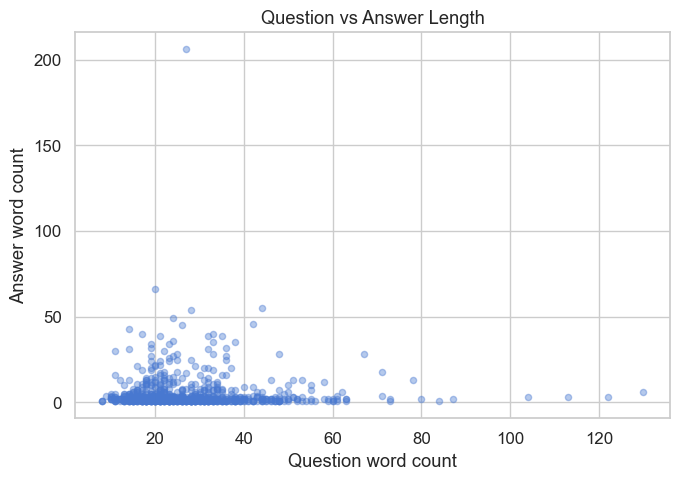

In [33]:
prompt_col = "Prompt"
answer_col = "Answer"

if prompt_col in df.columns and answer_col in df.columns:

    q_word_len = df[prompt_col].astype(str).apply(lambda x: len(x.split()))
    word_len = df[answer_col].astype(str).apply(lambda x: len(x.split()))

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(q_word_len, word_len, alpha=0.4, s=20)

    ax.set_xlabel("Question word count")
    ax.set_ylabel("Answer word count")
    ax.set_title("Question vs Answer Length")

    plt.tight_layout()
    plt.show()

else:
    print("Missing Prompt or Answer column")


## 4. Preprocessing

### 4.1 Normalise Text Fields

In [34]:
import re

def clean_text(text):
    # make sure input is a string
    if not isinstance(text, str):
        return ""

    # remove extra spaces
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    # remove weird control characters
    text = re.sub(r"[\x00-\x1f\x7f]", "", text)

    return text


# find text columns
text_cols = [c for c in df.columns if df[c].dtype == "object"]
print("Text columns:", text_cols)

df_clean = df.copy()

for col in text_cols:
    # only clean if column mostly contains strings
    if df_clean[col].apply(lambda x: isinstance(x, str) or pd.isna(x)).all():
        df_clean[col] = df_clean[col].apply(clean_text)

print("Done cleaning text")


Text columns: ['Prompt', 'Answer', 'wikipedia_link_1', 'wikipedia_link_2', 'wikipedia_link_3', 'wikipedia_link_4', 'wikipedia_link_5', 'wikipedia_link_6', 'wikipedia_link_7', 'wikipedia_link_8', 'wikipedia_link_9', 'wikipedia_link_10', 'wikipedia_link_11+', 'reasoning_types', 'wiki_links']
Done cleaning text


### 4.2 Drop / Fill Missing Values

In [35]:
before = len(df_clean)

# remove empty questions/answers
if prompt_col:
    df_clean = df_clean[df_clean[prompt_col].str.len() > 0]

if answer_col:
    df_clean = df_clean[df_clean[answer_col].str.len() > 0]

# reset index
df_clean = df_clean.reset_index(drop=True)

after = len(df_clean)

print(f"Before: {before}, After: {after}, Dropped: {before - after}")


Before: 824, After: 824, Dropped: 0


### 4.3 Handling reasoning types

Since each prompt-answer can have multiple reasoning types, we treat this as a multi-label problem. We split the reasoning types into lists and use an exploded representation for further analysis. This perserves combinations of reasoning types and keeps the structure of the original data, which will help us to analyze patterns and error types in RAG systems later on. 

In [36]:
df_clean["reasoning_list"] = (
    df_clean["reasoning_types"]
    .astype(str)
    .str.lower()
    .str.split("|")
    .apply(lambda x: [i.strip() for i in x])
)


In [37]:
df_exploded = df_clean.explode("reasoning_list")

In [38]:
df_exploded["reasoning_list"].value_counts()


reasoning_list
multiple constraints    549
numerical reasoning     293
temporal reasoning      278
tabular reasoning       236
post processing         107
Name: count, dtype: int64

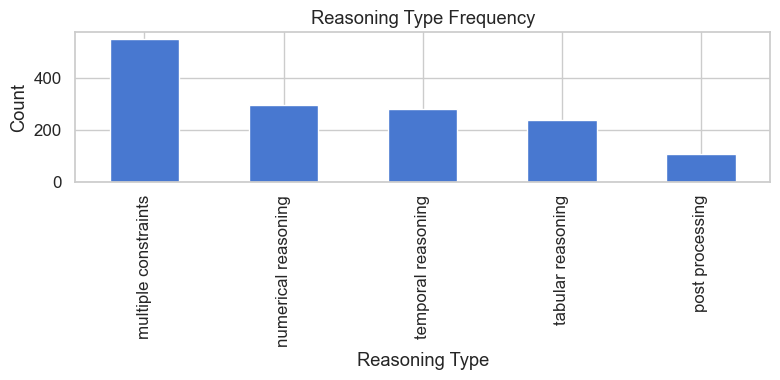

In [39]:
plt.figure(figsize=(8,4))
df_exploded["reasoning_list"].value_counts().plot(kind="bar")
plt.title("Reasoning Type Frequency")
plt.xlabel("Reasoning Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 4.5 Final Schema Overview

In [40]:
print(f'Final shape: {df_clean.shape}')
df_clean.dtypes

Final shape: (824, 17)


Unnamed: 0             int64
Prompt                object
Answer                object
wikipedia_link_1      object
wikipedia_link_2      object
wikipedia_link_3      object
wikipedia_link_4      object
wikipedia_link_5      object
wikipedia_link_6      object
wikipedia_link_7      object
wikipedia_link_8      object
wikipedia_link_9      object
wikipedia_link_10     object
wikipedia_link_11+    object
reasoning_types       object
wiki_links            object
reasoning_list        object
dtype: object

In [41]:
df_clean.head(3)

,Unnamed: 0,Prompt,Answer,wikipedia_link_1,wikipedia_link_2,wikipedia_link_3,wikipedia_link_4,wikipedia_link_5,wikipedia_link_6,wikipedia_link_7,wikipedia_link_8,wikipedia_link_9,wikipedia_link_10,wikipedia_link_11+,reasoning_types,wiki_links,reasoning_list
0,0,If my future wife has the same first name as the 15th first lady of the United States' mother and her surname is the...,Jane Ballou,https://en.wikipedia.org/wiki/President_of_the_United_States,https://en.wikipedia.org/wiki/James_Buchanan,https://en.wikipedia.org/wiki/Harriet_Lane,https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States_who_died_in_office,https://en.wikipedia.org/wiki/James_A._Garfield,,,,,,,Multiple constraints,"['https://en.wikipedia.org/wiki/President_of_the_United_States', 'https://en.wikipedia.org/wiki/James_Buchanan', 'ht...",[multiple constraints]
1,1,Imagine there is a building called Bronte tower whose height in feet is the same number as the dewey decimal classif...,37th,https://en.wikipedia.org/wiki/Charlotte_Bront%C3%AB,https://en.wikipedia.org/wiki/Jane_Eyre,https://en.wikipedia.org/wiki/List_of_tallest_buildings_in_New_York_City,,,,,,,,,Numerical reasoning | Tabular reasoning | Multiple constraints,"['https://en.wikipedia.org/wiki/Charlotte_Bront%C3%AB', 'https://en.wikipedia.org/wiki/Jane_Eyre', 'https://en.wikip...","[numerical reasoning, tabular reasoning, multiple constraints]"
2,2,How many years earlier would Punxsutawney Phil have to be canonically alive to have made a Groundhog Day prediction ...,87,https://en.wikipedia.org/wiki/Punxsutawney_Phil,https://en.wikipedia.org/wiki/United_States_Capitol,,,,,,,,,,Numerical reasoning | Multiple constraints | Temporal reasoning,"['https://en.wikipedia.org/wiki/Punxsutawney_Phil', 'https://en.wikipedia.org/wiki/United_States_Capitol']","[numerical reasoning, multiple constraints, temporal reasoning]"


## 5. Export

In [42]:
import os

# Make sure the folder exists
os.makedirs("dataset", exist_ok=True)

out_path = "dataset/frames_preprocessed.csv"

# Convert list columns to string (needed for CSV)
for col in df_clean.columns:
    if df_clean[col].apply(lambda x: isinstance(x, list)).any():
        df_clean[col] = df_clean[col].astype(str)

# Save as CSV
df_clean.to_csv(out_path, index=False)

print(f"Saved → {out_path} ({len(df_clean):,} rows, {df_clean.shape[1]} columns)")


Saved → dataset/frames_preprocessed.csv (824 rows, 17 columns)
